<img src="https://datasciencedegree.wisconsin.edu/wp-content/themes/data-gulp/images/logo.svg" width="300">

 # <center>DS 710 - Lesson 5</center>

This notebook will work through some of the basics of the NumPy package.

References for the material in this notebook include 
* Chapter 4 of *Python for Data Analysis*, titled <em> numpy Basics: Arrays and Vectorized Computation</em>, especially Sections 4.1, 4.3, and 4.4
* the <a href="https://numpy.org/doc/stable/">official numpy documentation</a>.

---


### Getting started with numpy

First, we'll import the numpy package, and look at the N-dimensional array (an <em>ndarray</em>) container. To create an ndarray from a sequence, we use the `array` function, demonstrated below. Notice that the resulting array is an ndarray of dimension 2.

In [1]:
import numpy as np

tuple_of_lists = ([0, 1, 2, 3], [4, 5, 6, 7])
print(type(tuple_of_lists))
make_an_array = np.array(tuple_of_lists)
print(type(make_an_array))
print(make_an_array.ndim)

<class 'tuple'>
<class 'numpy.ndarray'>
2


We can also make an ndarray consisting of entirely of zeros or a range of values:

In [2]:
zeros_array = np.zeros((4,2))
range_array = np.arange(303,350)

print(zeros_array)
print(range_array)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]]
[303 304 305 306 307 308 309 310 311 312 313 314 315 316 317 318 319 320
 321 322 323 324 325 326 327 328 329 330 331 332 333 334 335 336 337 338
 339 340 341 342 343 344 345 346 347 348 349]


We can also create ndarrays of all [---]s of the same shape and data type as another ndarray, where "[---]" can be "zeros", "ones", or any other value. For example:

In [3]:
print(np.zeros_like(make_an_array))
print(np.ones_like(make_an_array))
print(np.full_like(make_an_array, 3))

[[0 0 0 0]
 [0 0 0 0]]
[[1 1 1 1]
 [1 1 1 1]]
[[3 3 3 3]
 [3 3 3 3]]


Note that using `np.empty_like()` will allocate memory, but will not populate any values.

---

### Vectorization & statistical methods


The list `AZ_cities` gives four cities in Arizona. For each city, `temp_list` contains a list of the city's maximum daily temperatures in degrees Fahrenheit for each day of the month of October 2017, so that the corresponding array has 4 "rows" (dimension 0) and 31 "columns" (dimension 1) (Source: <a href="https://www.ncdc.noaa.gov/cdo-web/">NOAA Climate Data Online</a>).

In [4]:
AZ_cities = ['Flagstaff', 'Iron Springs', 'Mesa', 'Tucson']
temp_list = [[69, 68, 67, 71, 74, 71, 76, 73, 68, 64, 68, 68, 67, 71, 70, 73, 74, 72, 68, 66, 62, 71, 73, 69, 71, 70, 69, 65, 69, 68, 60],
            [76, 71, 76, 81, 81, 77, 83, 76, 67, 74, 77, 75, 75, 77, 80, 83, 82, 79, 78, 71, 68, 78, 85, 80, 80, 77, 76, 76, 77, 71, 68],
            [96, 95, 97, 98, 97, 95, 95, 94, 91, 94, 97, 94, 95, 92, 97, 99, 98, 94, 96, 91, 83, 91, 96, 100, 97, 94, 91, 90, 91, 87, 82],
            [96, 92, 95, 97, 97, 92, 92, 94, 84, 90, 96, 93, 93, 91, 93, 93, 95, 94, 93, 89, 81, 89, 94, 94, 93, 90, 87, 88, 89, 85, 78]
            ]
AZ_cities_array = np.array(AZ_cities)
temp_array = np.array(temp_list)

Below, we convert the list of temperatures to degrees Celsius, rounded to two decimal places, using a nested list comprehension.

In [5]:
celsius_temp_list=[[round((5/9)*(temp_list[i][j]-32),2) for j in range(31)] for i in range(4)]   

print(celsius_temp_list)

[[20.56, 20.0, 19.44, 21.67, 23.33, 21.67, 24.44, 22.78, 20.0, 17.78, 20.0, 20.0, 19.44, 21.67, 21.11, 22.78, 23.33, 22.22, 20.0, 18.89, 16.67, 21.67, 22.78, 20.56, 21.67, 21.11, 20.56, 18.33, 20.56, 20.0, 15.56], [24.44, 21.67, 24.44, 27.22, 27.22, 25.0, 28.33, 24.44, 19.44, 23.33, 25.0, 23.89, 23.89, 25.0, 26.67, 28.33, 27.78, 26.11, 25.56, 21.67, 20.0, 25.56, 29.44, 26.67, 26.67, 25.0, 24.44, 24.44, 25.0, 21.67, 20.0], [35.56, 35.0, 36.11, 36.67, 36.11, 35.0, 35.0, 34.44, 32.78, 34.44, 36.11, 34.44, 35.0, 33.33, 36.11, 37.22, 36.67, 34.44, 35.56, 32.78, 28.33, 32.78, 35.56, 37.78, 36.11, 34.44, 32.78, 32.22, 32.78, 30.56, 27.78], [35.56, 33.33, 35.0, 36.11, 36.11, 33.33, 33.33, 34.44, 28.89, 32.22, 35.56, 33.89, 33.89, 32.78, 33.89, 33.89, 35.0, 34.44, 33.89, 31.67, 27.22, 31.67, 34.44, 34.44, 33.89, 32.22, 30.56, 31.11, 31.67, 29.44, 25.56]]


Transforming loops into array expressions, where computations are performed on an entire array rather than looping through values, is called vectorization; this transformation can have a significant impact on runtime, especially in the case of numerical computations. 

🧠 In the cell below use vectorization to convert the values in the ndarray `temp_array` to degrees Celsius. 

In [7]:
celsius_temp_array = np.round((5/9)*(temp_array-32),2)
print(celsius_temp_array)

[[20.56 20.   19.44 21.67 23.33 21.67 24.44 22.78 20.   17.78 20.   20.
  19.44 21.67 21.11 22.78 23.33 22.22 20.   18.89 16.67 21.67 22.78 20.56
  21.67 21.11 20.56 18.33 20.56 20.   15.56]
 [24.44 21.67 24.44 27.22 27.22 25.   28.33 24.44 19.44 23.33 25.   23.89
  23.89 25.   26.67 28.33 27.78 26.11 25.56 21.67 20.   25.56 29.44 26.67
  26.67 25.   24.44 24.44 25.   21.67 20.  ]
 [35.56 35.   36.11 36.67 36.11 35.   35.   34.44 32.78 34.44 36.11 34.44
  35.   33.33 36.11 37.22 36.67 34.44 35.56 32.78 28.33 32.78 35.56 37.78
  36.11 34.44 32.78 32.22 32.78 30.56 27.78]
 [35.56 33.33 35.   36.11 36.11 33.33 33.33 34.44 28.89 32.22 35.56 33.89
  33.89 32.78 33.89 33.89 35.   34.44 33.89 31.67 27.22 31.67 34.44 34.44
  33.89 32.22 30.56 31.11 31.67 29.44 25.56]]


Suppose we wish to find the mean high temperature for the month of October across all four cities, rounded to two decimal places; we can use the `mean` function. 

In [8]:
np.round(temp_array.mean(),2)

np.float64(82.69)

We can also take means across particular axes of our array: if we wish to find the mean high temperature in each city for the month of October, we specify `axis=1`, which takes means across the "columns" of the 2-dimensional array (i.e means within each row).

In [11]:
np.round(temp_array.mean(axis=1),2)

array([69.19, 76.61, 93.77, 91.19])

🧠 What if we wished to find the mean high temperature for each day in October 2017, averaged across all four cities? Try it out below.

In [12]:
np.round(temp_array.mean(axis=0),2)

array([84.25, 81.5 , 83.75, 86.75, 87.25, 83.75, 86.5 , 84.25, 77.5 ,
       80.5 , 84.5 , 82.5 , 82.5 , 82.75, 85.  , 87.  , 87.25, 84.75,
       83.75, 79.25, 73.5 , 82.25, 87.  , 85.75, 85.25, 82.75, 80.75,
       79.75, 81.5 , 77.75, 72.  ])

Other array statistical methods can be found in Table 4-6 of your text in Section 4.4, "Array-Oriented Programming with Arrays".

---

### Pyplot

We will do more with plotting later, but note for now that pyplot allows us to create visualizations. We plot the temperature data for the four cities below.

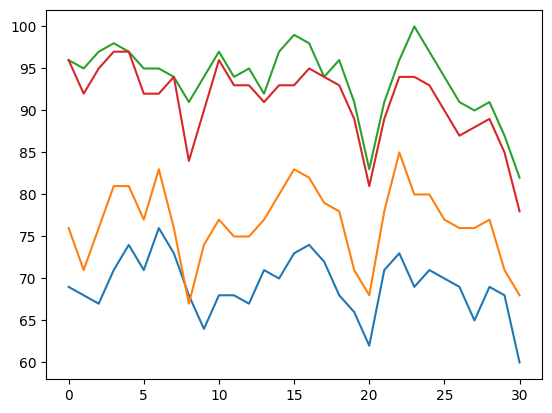

In [13]:
import matplotlib.pyplot as plt

plt.plot(temp_array[0])
plt.plot(temp_array[1])
plt.plot(temp_array[2])
plt.plot(temp_array[3])

---

### Indexing

#### Boolean indexing

Suppose we wish to pull out just the high temperatures for cities with at least one "a" in their names. With only four cities in our dataset, we could do this manually; however, with larger datasets, it will be convenient to use Boolean indexing, which allows us to select rows with particular properties. First, we create an ndarray of Booleans that indicates the characteristic we want.

In [14]:
print(np.char.count(AZ_cities_array, 'a') >= 1)

[ True False  True False]


Then, we ask for all "rows" (dimension 0) that correspond to cities with at least one "a", and all "columns" (dimension 1).

In [15]:
temp_array[np.char.count(AZ_cities_array, 'a') >= 1, :]

array([[ 69,  68,  67,  71,  74,  71,  76,  73,  68,  64,  68,  68,  67,
         71,  70,  73,  74,  72,  68,  66,  62,  71,  73,  69,  71,  70,
         69,  65,  69,  68,  60],
       [ 96,  95,  97,  98,  97,  95,  95,  94,  91,  94,  97,  94,  95,
         92,  97,  99,  98,  94,  96,  91,  83,  91,  96, 100,  97,  94,
         91,  90,  91,  87,  82]])

🧠 Try practicing Boolean indexing using a different characteristic below.

In [17]:
# your code here
temp_array[temp_array >= 90]

array([ 96,  95,  97,  98,  97,  95,  95,  94,  91,  94,  97,  94,  95,
        92,  97,  99,  98,  94,  96,  91,  91,  96, 100,  97,  94,  91,
        90,  91,  96,  92,  95,  97,  97,  92,  92,  94,  90,  96,  93,
        93,  91,  93,  93,  95,  94,  93,  94,  94,  93,  90])

#### Fancy indexing



Fancy indexing allows us to pull out and rearrange the values in one dimension of the ndarray. For example, suppose we wanted to order our temperature data so that it corresponded to the cities in reverse alphabetical order instead:

In [18]:
rev_alpha_temps = temp_array[[3, 2, 1, 0]]
print(rev_alpha_temps)

[[ 96  92  95  97  97  92  92  94  84  90  96  93  93  91  93  93  95  94
   93  89  81  89  94  94  93  90  87  88  89  85  78]
 [ 96  95  97  98  97  95  95  94  91  94  97  94  95  92  97  99  98  94
   96  91  83  91  96 100  97  94  91  90  91  87  82]
 [ 76  71  76  81  81  77  83  76  67  74  77  75  75  77  80  83  82  79
   78  71  68  78  85  80  80  77  76  76  77  71  68]
 [ 69  68  67  71  74  71  76  73  68  64  68  68  67  71  70  73  74  72
   68  66  62  71  73  69  71  70  69  65  69  68  60]]


Note that fancy indexing will create a copy of the data into a new ndarray, so that we can change values without affecting the original ndarray. For example, suppose we replace Tucson's temperatures with the mean high temperature in Tucson during October; this will not change the values in `temp_array`.

In [19]:
rev_alpha_temps[0] = rev_alpha_temps.mean(axis = 1)[0]
print(rev_alpha_temps)
print(temp_array)

[[ 91  91  91  91  91  91  91  91  91  91  91  91  91  91  91  91  91  91
   91  91  91  91  91  91  91  91  91  91  91  91  91]
 [ 96  95  97  98  97  95  95  94  91  94  97  94  95  92  97  99  98  94
   96  91  83  91  96 100  97  94  91  90  91  87  82]
 [ 76  71  76  81  81  77  83  76  67  74  77  75  75  77  80  83  82  79
   78  71  68  78  85  80  80  77  76  76  77  71  68]
 [ 69  68  67  71  74  71  76  73  68  64  68  68  67  71  70  73  74  72
   68  66  62  71  73  69  71  70  69  65  69  68  60]]
[[ 69  68  67  71  74  71  76  73  68  64  68  68  67  71  70  73  74  72
   68  66  62  71  73  69  71  70  69  65  69  68  60]
 [ 76  71  76  81  81  77  83  76  67  74  77  75  75  77  80  83  82  79
   78  71  68  78  85  80  80  77  76  76  77  71  68]
 [ 96  95  97  98  97  95  95  94  91  94  97  94  95  92  97  99  98  94
   96  91  83  91  96 100  97  94  91  90  91  87  82]
 [ 96  92  95  97  97  92  92  94  84  90  96  93  93  91  93  93  95  94
   93  89  81  89  94 

🧠 Observe what happens when we try to use fancy indexing on multiple dimensions of the data at a time. Try to determine where the returned values are coming from.

In [20]:
rev_alpha_temps[[1, 3],[0, 30]]

array([96, 60])

🧠 How could you pull out rows with indices 1 and 3, and and columns with indices 0 and 30 to get a 2-dimensional ndarray rather than what was returned above? Try out your ideas below.

In [21]:
temp_array[[1,2,3], :]

array([[ 76,  71,  76,  81,  81,  77,  83,  76,  67,  74,  77,  75,  75,
         77,  80,  83,  82,  79,  78,  71,  68,  78,  85,  80,  80,  77,
         76,  76,  77,  71,  68],
       [ 96,  95,  97,  98,  97,  95,  95,  94,  91,  94,  97,  94,  95,
         92,  97,  99,  98,  94,  96,  91,  83,  91,  96, 100,  97,  94,
         91,  90,  91,  87,  82],
       [ 96,  92,  95,  97,  97,  92,  92,  94,  84,  90,  96,  93,  93,
         91,  93,  93,  95,  94,  93,  89,  81,  89,  94,  94,  93,  90,
         87,  88,  89,  85,  78]])

---

## Random Sampling - For Simulation

Our next task is to introduce numpy methods for random simulation.  In this case, let's imagine the folling setting:

> You're an analyst for *Farm2Table*, a restaurant that sources its food locally whenever possible.  You are tasked to analyze the financial payoff of an ad campaign.  
> 
> Currently, average monthly revenue at each store is $100,000, **normally distributed**, with a standard deviation of $12,000.  An advertising firm claims that with clever advertisement, they can increase monthly revenue for *Farm2Table* to $120,000, but the standard deviation will be increased as well, to $25,000.  

We will use this information to create a simulation.  Let's begin by generating an array with 24 months of pre-advertisement data.

🧠Then you, adjust the simulation to also generate 12 months of post-advertisement data.

💡 Note that `np.random.normal` generally takes 3 arguments: 
* The first is the mean values
* The second is the standard deviation
* The third is shape of the array, which could be a single number or even a tuple listing multiple dimensions.

⚠ The random number generation is approximate, if you actually compute the mean or standard deviation of the arrays you generated, they will not be exactly the values you input.  How could it be random if it wasn't??

In [23]:
revenue_before = np.random.normal(100000,12000,24) 
revenue_after = np.random.normal(120000, 25000, 12)

🧠 Use `np.concatenate` to join `revenue_before` and `revenue_after` into a single array, `revenue_simulation`.

In [24]:
revenue_simulation = np.concatenate([revenue_before, revenue_after])

### Plotting The Data

Next let's go ahead and generate a graphical simulation of the data using `matplotlib`, which we mentioned earlier in the notebook.

🧠 Use `plt.plot()` as described earlier in this notebook to plot the values in `revenue simulation` so that the `x`-axis is the month number, after the initial measurement 24 months before the ad is run and the `y`-axis is the predicted revenue for the given month.

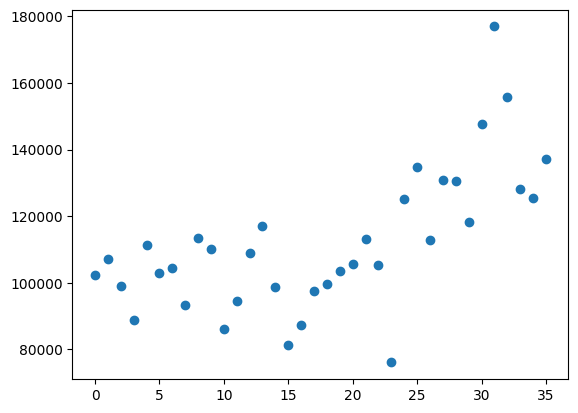

In [27]:
plt.scatter(y=revenue_simulation,x=range(0,36))
plt.savefig("notebook5_revenue_simulation_plot.pdf")


We can actually even now save this figure using by adding this line to the code cell with the scatter plot.

`plt.savefig("notebook5_revenue_simulation_plot.pdf")`

🧠 do this! 🙂

---

## When you're done

🧠 After completing the guided practice above, log onto Canvas to complete Quiz 5. You may wish to keep this notebook open while you work.

In [28]:
consec = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
np.ones_like(consec)

array([[[1, 1],
        [1, 1]],

       [[1, 1],
        [1, 1]]])

In [32]:
np.array([[[1, 2], [3, 4]], [[5,6], [7,8]]]).shape

(2, 2, 2)

In [37]:
consec = np.array([[[1, 2], [3, 4]], [[5,6], [7,8]]])
consec.shape

(2, 2, 2)

In [36]:
temp_array.size

124

In [41]:
array_ex = np.array([[1, 2], [3, 4], [5,6], [7,8]])
array_ex.mean(axis=1).ndim

1

In [42]:
pi_e_array=np.array([[3, 1, 4, 1, 5, 9, 2], [2, 7, 1, 8, 2, 8, 1]])
print(pi_e_array[[1, 0]][:,4])

[2 5]


In [43]:
data = np.random.beta(a=1,b=2, size=(23,13,510,2))

In [44]:
data[12,:,2:5,:].shape

(13, 3, 2)